In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris-flower-dataset/Iris.csv


# Let's import some libraries that we will be using


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading and Inspecting the data:


In [54]:
df = pd.read_csv("/kaggle/input/iris-flower-dataset/Iris.csv")
df.info()
df.head()
df.tail()
df.shape
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Acessing the data

In [66]:
print(df["SepalLengthCm"])
print(df.loc[df["Species"]=="Iris-setosa","SepalLengthCm"])
#df.iloc[::-1]
print(df[["SepalWidthCm","Species"]].head())

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: SepalLengthCm, Length: 150, dtype: float64
0     5.1
1     4.9
2     4.7
3     4.6
4     5.0
5     5.4
6     4.6
7     5.0
8     4.4
9     4.9
10    5.4
11    4.8
12    4.8
13    4.3
14    5.8
15    5.7
16    5.4
17    5.1
18    5.7
19    5.1
20    5.4
21    5.1
22    4.6
23    5.1
24    4.8
25    5.0
26    5.0
27    5.2
28    5.2
29    4.7
30    4.8
31    5.4
32    5.2
33    5.5
34    4.9
35    5.0
36    5.5
37    4.9
38    4.4
39    5.1
40    5.0
41    4.5
42    4.4
43    5.0
44    5.1
45    4.8
46    5.1
47    4.6
48    5.3
49    5.0
Name: SepalLengthCm, dtype: float64
   SepalWidthCm      Species
0           3.5  Iris-setosa
1           3.0  Iris-setosa
2           3.2  Iris-setosa
3           3.1  Iris-setosa
4           3.6  Iris-setosa


# Basic Numpy operations:

In [56]:
print("Mean:",np.mean(df["PetalLengthCm"]))
print("Min:",np.min(df["PetalLengthCm"]))
print("Max:",np.max(df["PetalLengthCm"]))
print("Std:",np.std(df["PetalLengthCm"]))
print("Variance:",np.var(df["PetalLengthCm"]))

Mean: 3.758666666666666
Min: 1.0
Max: 6.9
Std: 1.7585291834055201
Variance: 3.0924248888888854


# Analysing the data

In [57]:
#Comparing species and aggregations
df.groupby("Species")["PetalWidthCm"].mean()

Species
Iris-setosa        0.244
Iris-versicolor    1.326
Iris-virginica     2.026
Name: PetalWidthCm, dtype: float64

In [58]:
#Sorting and ranking:
df.sort_values("SepalLengthCm",ascending=False)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
131,132,7.9,3.8,6.4,2.0,Iris-virginica
122,123,7.7,2.8,6.7,2.0,Iris-virginica
118,119,7.7,2.6,6.9,2.3,Iris-virginica
117,118,7.7,3.8,6.7,2.2,Iris-virginica
135,136,7.7,3.0,6.1,2.3,Iris-virginica
...,...,...,...,...,...,...
41,42,4.5,2.3,1.3,0.3,Iris-setosa
42,43,4.4,3.2,1.3,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
38,39,4.4,3.0,1.3,0.2,Iris-setosa


# Let's start visualizing ascpects of our data through pyplot(matplotlib):

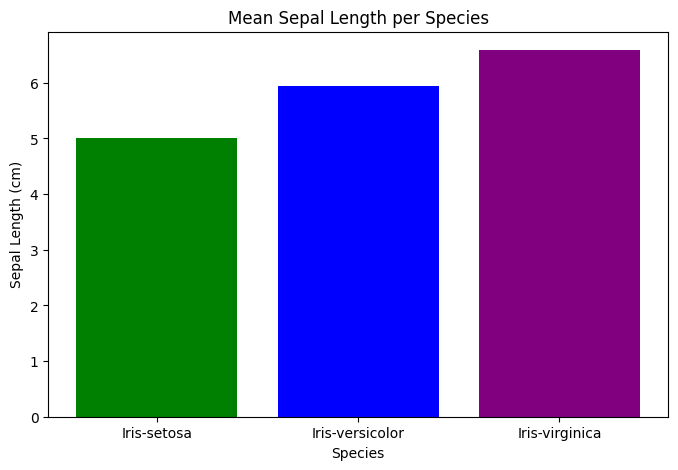

In [59]:
import matplotlib.pyplot as plt

mean_sepal_length = df.groupby("Species")["SepalLengthCm"].mean()

plt.figure(figsize=(8, 5))
plt.bar(mean_sepal_length.index, mean_sepal_length.values,
        color=["green", "blue", "purple"])

plt.title("Mean Sepal Length per Species")
plt.xlabel("Species")
plt.ylabel("Sepal Length (cm)")
plt.show()


# A plot representing the distribution of iris between its SepalLength and width

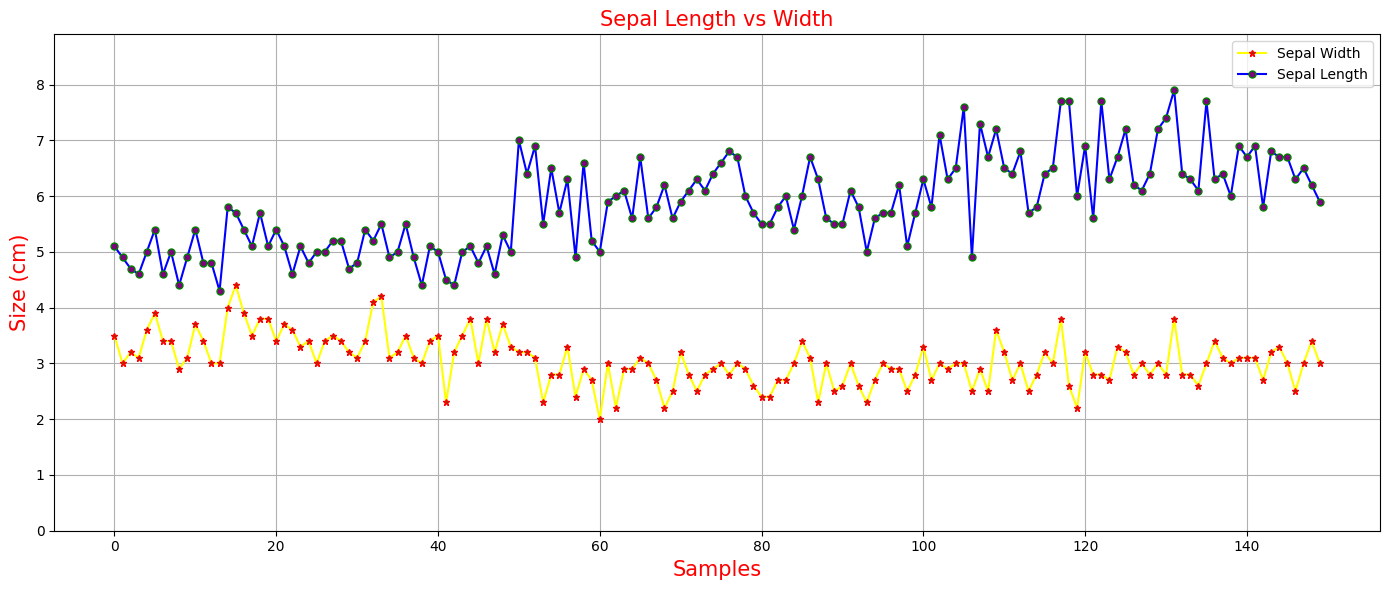

In [60]:
import matplotlib.pyplot as plt
import numpy as np

species = np.array(df["Species"])
sl = df["SepalLengthCm"].to_numpy()
sw = df["SepalWidthCm"].to_numpy()

plt.figure(figsize=(14, 6))

my_style = dict(marker="*", markersize=5,
                markeredgecolor="red",
                markerfacecolor="green",
                color="yellow")

my_style1 = dict(marker=".", markersize=10,
                 markeredgecolor="green",
                 markerfacecolor="purple",
                 color="blue")

plt.title("Sepal Length vs Width", fontsize=15, color="red")
plt.xlabel("Samples", fontsize=15, color="red")
plt.ylabel("Size (cm)", fontsize=15, color="red")

plt.plot(sw, **my_style, label="Sepal Width")
plt.plot(sl, **my_style1, label="Sepal Length")

plt.ylim(0, max(sl.max(), sw.max()) + 1)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


# Let's try the BarGraph:

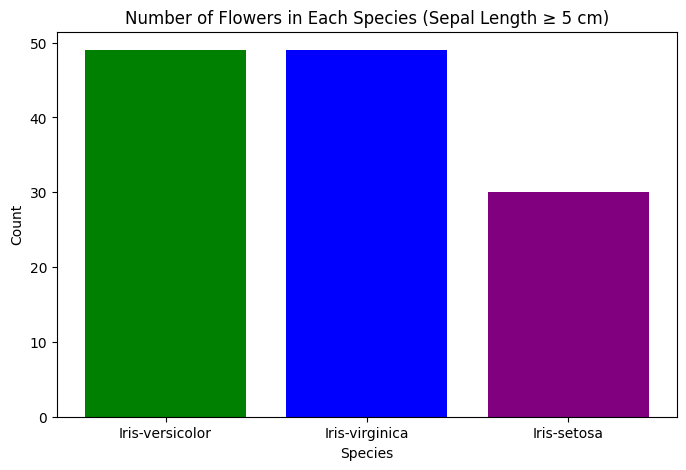

In [61]:
filtered_df = df[df["SepalLengthCm"] >= 5]
counts = filtered_df["Species"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values,
        color=["green", "blue", "purple"])

plt.title("Number of Flowers in Each Species (Sepal Length ≥ 5 cm)")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()


# Mean petal length per species:

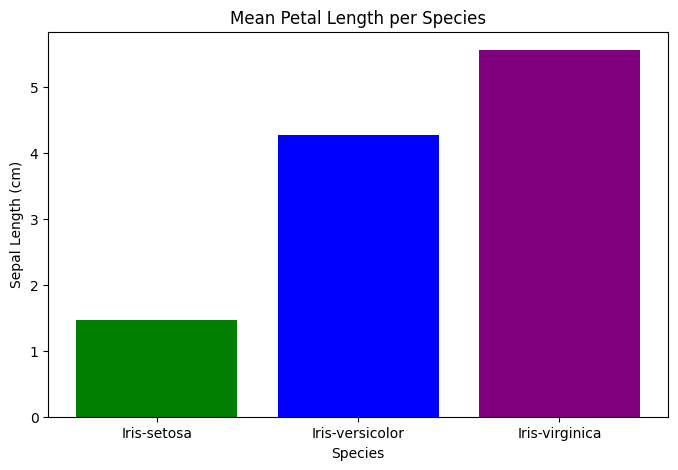

In [62]:
import matplotlib.pyplot as plt

mean_sepal_length = df.groupby("Species")["PetalLengthCm"].mean()

plt.figure(figsize=(8, 5))
plt.bar(mean_sepal_length.index, mean_sepal_length.values,
        color=["green", "blue", "purple"])

plt.title("Mean Petal Length per Species")
plt.xlabel("Species")
plt.ylabel("Sepal Length (cm)")
plt.show()


# Mean of septal vs Petal length

                    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Species                                                              
Iris-setosa       25.5          5.006         3.418          1.464   
Iris-versicolor   75.5          5.936         2.770          4.260   
Iris-virginica   125.5          6.588         2.974          5.552   

                 PetalWidthCm  
Species                        
Iris-setosa             0.244  
Iris-versicolor         1.326  
Iris-virginica          2.026  


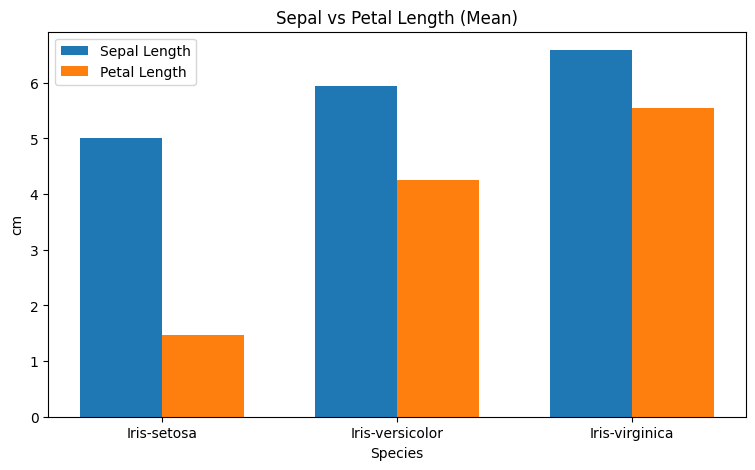

In [63]:
import numpy as np

grouped = df.groupby("Species").mean()
print(grouped)

x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, grouped["SepalLengthCm"], width, label="Sepal Length")
plt.bar(x + width/2, grouped["PetalLengthCm"], width, label="Petal Length")

plt.xticks(x, grouped.index)
plt.xlabel("Species")
plt.ylabel("cm")
plt.title("Sepal vs Petal Length (Mean)")
plt.legend()
plt.show()


# Scatter by Length:

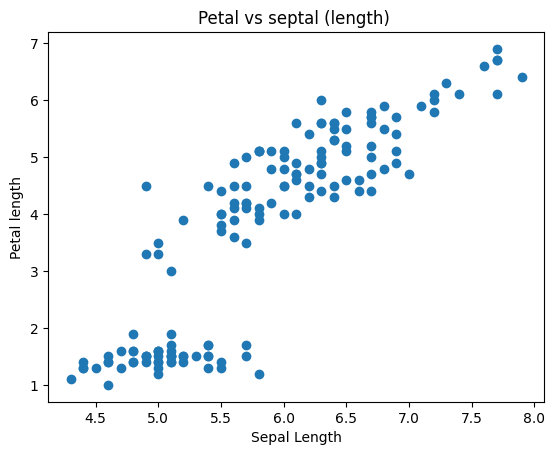

In [64]:
plt.scatter(df["SepalLengthCm"], df["PetalLengthCm"])
plt.title("Petal vs septal (length) ")
plt.xlabel("Sepal Length")
plt.ylabel("Petal length")
plt.show()


# Scatter by Species:


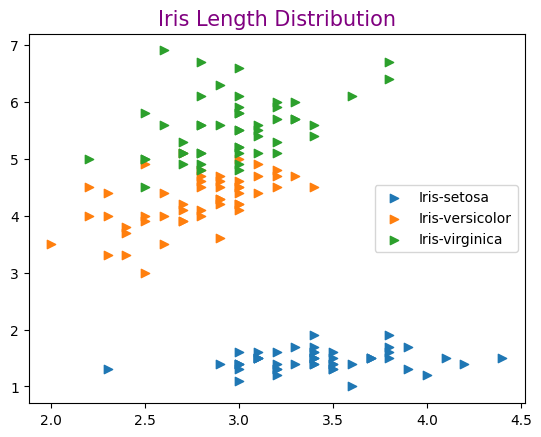

In [65]:
for species in df["Species"].unique():
    subset = df[df["Species"] == species]
    plt.scatter(subset["SepalWidthCm"], subset["PetalLengthCm"],marker=">", label=species)
plt.title("Iris Length Distribution",color="Purple",size=15)
plt.title("Iris Length Distribution",color="Purple",size=15)
plt.title("Iris Length Distribution",color="Purple",size=15)
plt.legend()
plt.show()
